In [61]:
import numpy as np 
import requests
import matplotlib.pyplot as plt

In [62]:
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

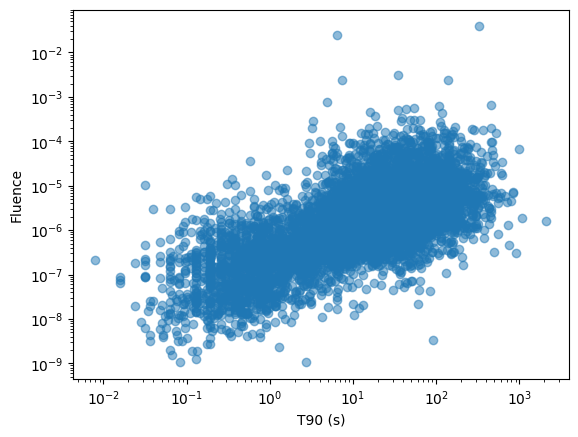

In [63]:
t = data[names=='T90']
f = data[names=='fluence']

flux= np.float64(f[(f!='-999') & (t!='-999')])
time= np.float64(t[(f!='-999') & (t!='-999')])

plt.scatter(time,flux, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('T90 (s)')
plt.ylabel('Fluence')
plt.show()

### K_MEANS with two clusters

Text(0.5, 1.0, 'Clustering output')

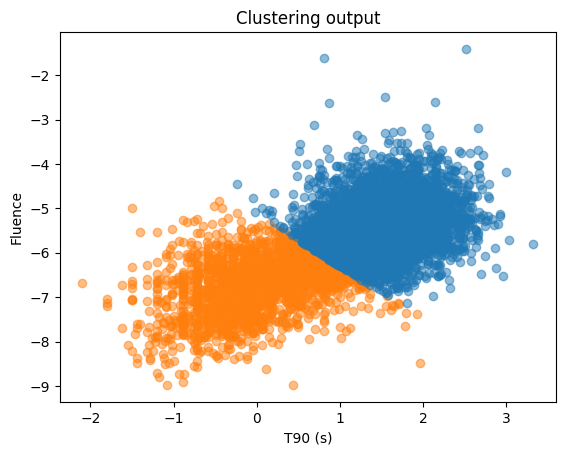

In [64]:
from sklearn.cluster import KMeans
from sklearn import preprocessing

#x has to be [n_samples, n_features]
X = np.vstack([np.log10(time[(time!=0) & (flux!=0)]), np.log10(flux[(time!=0) & (flux!=0)])]).T

clf = KMeans(n_clusters=2,n_init='auto')                #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_      #location of the clusters
labels =  clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0']
for ii in range(2):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.5)

plt.xlabel('T90 (s)')
plt.ylabel('Fluence')
plt.title('Clustering output')

### MEAN SHIFTING with two clusters

In [65]:
# Compute the Mean-shift clustering
from sklearn.cluster import MeanShift, estimate_bandwidth

scaler = preprocessing.StandardScaler()
#bandwidth = 1.4 
bandwidth = estimate_bandwidth(X) # this takes a long time...beware
ms = MeanShift(bandwidth=bandwidth, bin_seeding=False, cluster_all=True)
ms.fit(scaler.fit_transform(X))

MeanShift(bandwidth=0.9172177161417292)

In [66]:
labels_unique = np.unique(ms.labels_)

#usually labels< 0 are noise or points not assigned to any cluster
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[0 1 2 3]
0.9172177161417292
number of estimated clusters : 4


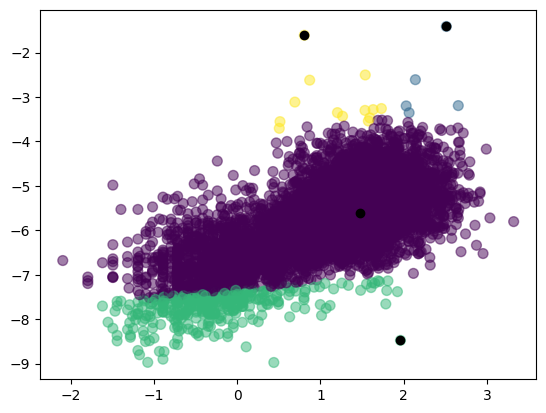

In [67]:
plt.scatter(X[:,0], X[:,1], c=ms.labels_, s=50, alpha=0.5)
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='o', color='black', label='centers')

It seems to be not the best algorithm in this case, let's try with PCA

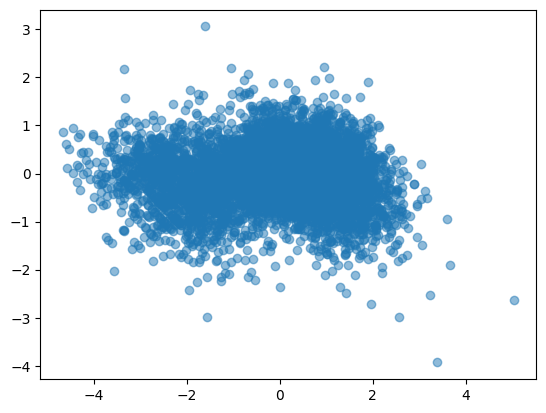

In [100]:
from sklearn.decomposition import PCA

x_scal= preprocessing.StandardScaler()
pca = PCA(n_components=2) # 2 components
X_pca = pca.fit_transform(x_scal.fit_transform(X))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)


### Let's focus in time (they are called SHORT and LONG gamma ray burts)

In [69]:
grb=dict(zip(names,data))
for lab in ['T90',"redshift","T90_error"]:
    grb[lab] = np.array(grb[lab],dtype='float')

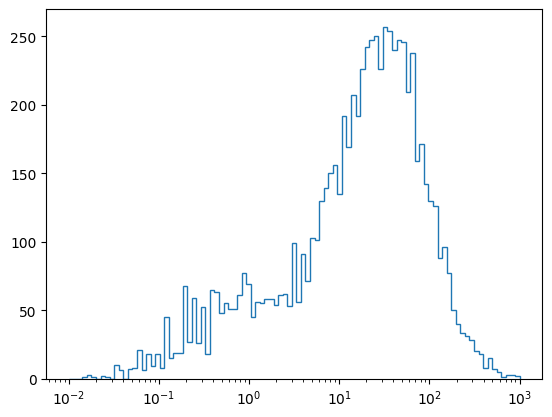

In [70]:
plt.hist(grb['T90'],bins= np.logspace(-2,3,100), histtype='step');
plt.semilogx();

### CROSS VALIDATION in order to fin the best KDE bandwidth

In [71]:
# Preparing data
lT90 = np.log10(grb['T90'][grb['T90']> 0]) #log10 of T90, only positive values
lT90=lT90[~np.isnan(lT90)] 
skT90 = lT90[:,np.newaxis]

In [72]:
from sklearn.neighbors import KernelDensity

xgrid=np.logspace(-3,3,100)

def kde_sklearn(data, bandwidth = 1.0):
    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data) #fit the model to the data
    log_pdf = kde.score_samples(np.log10(xgrid)[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

from sklearn.model_selection import GridSearchCV

bwrange = np.linspace(0.01,2.0, 10) 

K = 5 # Do 5-fold cross validation

grid = GridSearchCV(KernelDensity(), {'bandwidth': bwrange}, cv= K) # Try each bandwidth with K-folds
grid.fit(skT90) 
h_opt = grid.best_params_['bandwidth']
print(h_opt)

0.23111111111111113


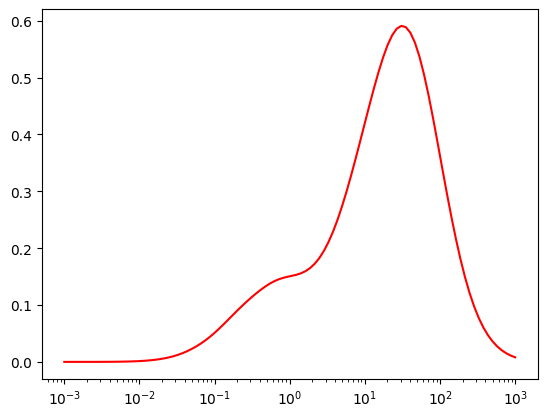

In [73]:
pdf = kde_sklearn(skT90,h_opt)
plt.plot(xgrid,pdf,c='red')
plt.semilogx();

### There are two modes: we can separate them using K-MEANS or MEAN SHIFTING

#### K_MEANS

In [74]:
# We try with 2 modes
clf = KMeans(n_clusters=2, n_init='auto') 
clf.fit(skT90)

KMeans(n_clusters=2)

In [75]:
centers = clf.cluster_centers_
centers = 10**np.squeeze(centers)
centers #in seconds

array([ 0.87665136, 32.61087923])

Prediction for each sample

In [76]:
labels = clf.predict(skT90)

#if the first center is larger than the second, we reverse the order
if centers[0]>centers[1]:
    centers=centers[::-1] # Reverse array
    labels = np.array(~np.array(labels,dtype='bool'),dtype='int') # Swap 0 <--> 1
centers, labels

(array([ 0.87665136, 32.61087923]),
 array([0, 1, 1, ..., 0, 1, 0], dtype=int32))

They are centroids of the two clusters but we want the edge between the two

5.330966141329357


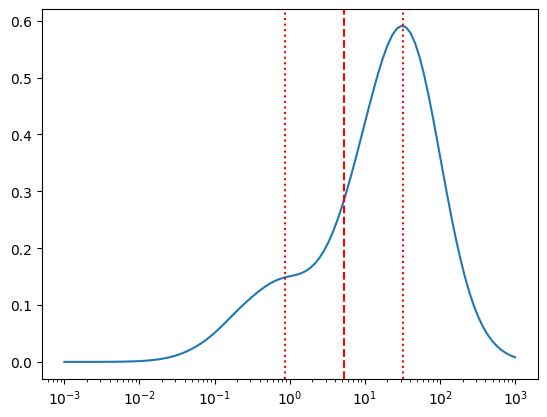

In [77]:
# the mean between the maximum of the first cluster and the minimum of the second cluster
edge = 10**( np.mean( [max(skT90[labels==0]), min(skT90[labels==1]) ]))

print(edge)

plt.plot(xgrid,pdf)
plt.semilogx()
for v in centers:
    plt.axvline(v, c='red',ls='dotted')
plt.axvline(edge,c='red',ls='dashed');

#### MEAN SHIFTING

In [89]:
scaler2 = preprocessing.StandardScaler() 
bandwidth = 0.35
ms2 = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
ms2.fit(scaler2.fit_transform(skT90))

MeanShift(bandwidth=0.35, bin_seeding=True, cluster_all=False)

In [90]:
labels_unique = np.unique(ms2.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[-1  0  1]
0.35
number of estimated clusters : 2


In [91]:
#inverse transform the cluster centers
cluster_centers = scaler2.inverse_transform(ms2.cluster_centers_)
cluster_centers=10**np.squeeze(cluster_centers)
print(cluster_centers)

labels2= ms2.predict(scaler2.transform(skT90))


[32.13636508  0.94499189]


[ 0.94499189 32.13636508]


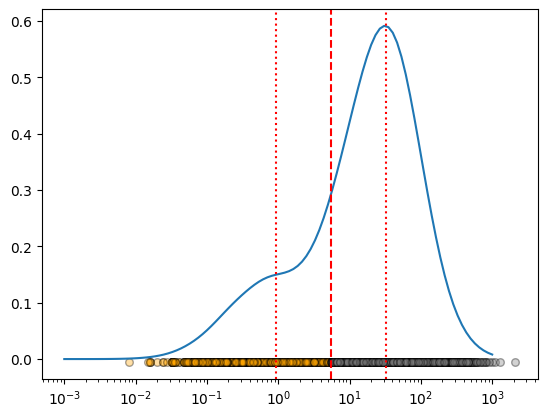

In [ ]:
data_linear = 10**skT90

if cluster_centers[0]>cluster_centers[1]:
    cluster_centers=cluster_centers[::-1] # Reverse array
    labels2 = np.logical_not(labels2).astype(int) # Swap 0 <--> 1


edge2 = np.mean([max(data_linear[labels2 == 0]), min(data_linear[labels2 == 1])])

plt.plot(xgrid,pdf)
plt.semilogx()

colors = ['orange', 'grey', 'blue', 'green', 'purple', 'brown']
for label in np.unique(labels2):
    plt.scatter(data_linear[labels2 == label], np.zeros_like(data_linear[labels2 == label]) - 0.005,  color=colors[label],s=30, facecolors=colors[label], 
                edgecolors='k',
                alpha=0.35,
                label=f'Cluster {label}')
    
for v in cluster_centers:
    plt.axvline(v, c='red',ls='dotted')
plt.axvline(edge2,c='red',ls='dashed');
plt.semilogx()
plt.show()


In [82]:
print(edge)
print(edge2)  

print(f"centers K-means: {centers}")
print(f"centers Mean-shift: {cluster_centers}")

5.330966141329357
5.512
centers K-means: [ 0.87665136 32.61087923]
centers Mean-shift: [ 0.94499189 32.13636508]


### MEAN SHIFTING with the optimal KDE width

In [96]:
scaler2 = preprocessing.StandardScaler() 
bandwidth = h_opt
ms2 = MeanShift(bandwidth=bandwidth, bin_seeding=True, cluster_all=False)
ms2.fit(scaler2.fit_transform(skT90))

#with the optimal does not work

MeanShift(bandwidth=0.23111111111111113, bin_seeding=True, cluster_all=False)

In [97]:
labels_unique = np.unique(ms2.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)
print(bandwidth)
print("number of estimated clusters :", n_clusters)

[-1  0  1  2  3  4  5  6]
0.23111111111111113
number of estimated clusters : 7


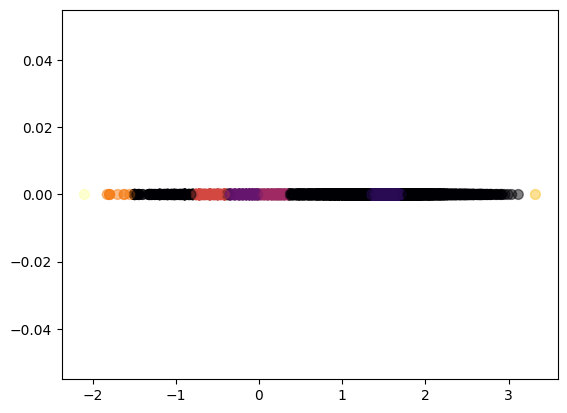

In [99]:
plt.scatter(skT90, np.zeros_like(skT90), c=ms2.labels_, s=50, alpha=0.5, cmap='inferno')